#### 1. IMPORT LIBRARIES

In [12]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn 
!pip install sklearn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import chi2_contingency

#### 2. DATA LOADING AND INITIAL EXPLORATION

In [14]:
# Load the dataset
df = pd.read_csv('C:/Users/SRIVIDYA GAJJALA/Datasets/Significant_Earthquakes.csv')

# Display sample data
print("Sample Data:")
print(df.sample(10))
print("\n" + "="*80 + "\n")

# Basic information
print("Dataset Information:")
df.info()
print("\n" + "="*80 + "\n")

# Dataset shape
print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n" + "="*80 + "\n")

# Column names
print("Column Names:")
print(df.columns.tolist())
print("\n" + "="*80 + "\n")

Sample Data:
        Unnamed: 0                      time  latitude  longitude    depth  \
73798        73798  2010-06-13T08:41:21.400Z   22.8660  -107.8160   10.000   
10763        10763  1963-10-20T17:41:29.180Z   44.3660   149.9270   41.400   
63584        63584  2005-03-09T13:02:05.850Z  -20.7260   169.2780   10.000   
79892        79892  2013-05-21T18:52:00.190Z   -6.5210   154.5780   58.300   
100507      100507  2024-01-15T21:56:59.759Z  -30.6679  -178.0131   34.831   
83351        83351  2015-08-14T13:43:12.760Z  -27.0844  -176.0072   10.000   
35911        35911  1986-04-20T09:17:18.250Z  -10.9140   161.0190   33.000   
61286        61286  2003-12-19T00:11:58.230Z   19.8520    95.6980   10.000   
106557      106557  2025-03-30T15:26:16.020Z  -20.5987  -173.6038   37.643   
67887        67887  2007-08-12T09:55:50.030Z    1.0670   123.8610  278.300   

         mag magType    nst    gap   dmin  ...                   updated  \
73798   5.00     mwc  116.0  199.0    NaN  ...  2016

#### 3. MISSING VALUE ANALYSIS

In [15]:
print("Missing Value Analysis:")
print("-" * 80)

# Count missing values
missing_count = df.isnull().sum()
print("Missing Value Counts:")
print(missing_count[missing_count > 0])
print("\n")

# Calculate missing value percentage
missing_percent = round(df.isnull().sum() * 100 / len(df), 2)
print("Missing Value Percentage:")
print(missing_percent[missing_percent > 0])
print("\n" + "="*80 + "\n")

Missing Value Analysis:
--------------------------------------------------------------------------------
Missing Value Counts:
depth                285
nst                70641
gap                60350
dmin               80294
rms                28747
place                891
horizontalError    81674
depthError         49715
magError           67061
magNst             60025
dtype: int64


Missing Value Percentage:
depth               0.26
nst                64.06
gap                54.73
dmin               72.82
rms                26.07
place               0.81
horizontalError    74.07
depthError         45.09
magError           60.82
magNst             54.44
dtype: float64




#### 4. HANDLING MISSING VALUES

In [16]:
print("Handling Missing Values:")
print("-" * 80)

# Step 4.1: Drop columns with >30% missing values
threshold = 30
cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()
print(f"Columns dropped (>{threshold}% missing): {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Shape after dropping columns: {df.shape}\n")

# Step 4.2: Drop ID-like and irrelevant columns
id_like_cols = ['Unnamed: 0', 'id', 'net', 'locationSource', 'magSource', 'place', 'updated']
existing_id_cols = [col for col in id_like_cols if col in df.columns]
print(f"Dropping ID-like/irrelevant columns: {existing_id_cols}")
df.drop(columns=existing_id_cols, inplace=True, errors='ignore')
print(f"Shape after dropping ID columns: {df.shape}\n")

# Step 4.3: Drop rows with missing 'depth' values
initial_rows = len(df)
df = df.dropna(subset=['depth'])
print(f"Rows dropped due to missing depth: {initial_rows - len(df)}")
print(f"Shape after dropping missing depth rows: {df.shape}\n")

# Step 4.4: Regression-based imputation for 'rms' column
if 'rms' in df.columns and df['rms'].isnull().sum() > 0:
    print("Applying regression-based imputation for 'rms'...")
    
    # Select predictor features
    predictors = ['mag', 'depth', 'nst', 'gap', 'dmin']
    available_features = [f for f in predictors if f in df.columns]
    
    # Separate known and missing RMS data
    df_known = df[df['rms'].notnull()].dropna(subset=available_features)
    df_missing = df[df['rms'].isnull()].dropna(subset=available_features)
    
    # Train and predict if sufficient data exists
    if not df_known.empty and not df_missing.empty:
        X_train = df_known[available_features]
        y_train = df_known['rms']
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        
        # Impute missing values
        X_missing = df_missing[available_features]
        df.loc[df['rms'].isnull() & df.index.isin(df_missing.index), 'rms'] = model.predict(X_missing)
        
        print(f"RMS missing values after imputation: {df['rms'].isnull().sum()}")
    else:
        print("Insufficient data for regression imputation")
else:
    print("No 'rms' column or no missing values in 'rms'")

print("\n" + "="*80 + "\n")

# Check remaining missing values
print("Remaining Missing Values:")
remaining_missing = round(df.isnull().sum() * 100 / len(df), 2)
print(remaining_missing[remaining_missing > 0])
print("\n" + "="*80 + "\n")

Handling Missing Values:
--------------------------------------------------------------------------------
Columns dropped (>30% missing): ['nst', 'gap', 'dmin', 'horizontalError', 'depthError', 'magError', 'magNst']
Shape after dropping columns: (110265, 16)

Dropping ID-like/irrelevant columns: ['Unnamed: 0', 'id', 'net', 'locationSource', 'magSource', 'place', 'updated']
Shape after dropping ID columns: (110265, 9)

Rows dropped due to missing depth: 285
Shape after dropping missing depth rows: (109980, 9)

Applying regression-based imputation for 'rms'...
RMS missing values after imputation: 0


Remaining Missing Values:
Series([], dtype: float64)




#### # 5. FEATURE ENGINEERING-1

In [17]:
# ============================================================================
# 5. FEATURE ENGINEERING
# ============================================================================

print("Feature Engineering:")
print("-" * 80)

# Step 5.1: Temporal feature extraction from 'time' column
if 'time' in df.columns:
    print("Extracting temporal features from 'time' column...")
    
    # Convert to datetime
    df['Datetime'] = pd.to_datetime(df['time'], errors='coerce')
    
    # Extract time components
    df['Year'] = df['Datetime'].dt.year
    df['Month'] = df['Datetime'].dt.month
    df['Day'] = df['Datetime'].dt.day
    df['Hour'] = df['Datetime'].dt.hour
    df['Minute'] = df['Datetime'].dt.minute
    df['Second'] = df['Datetime'].dt.second
    df['DayOfWeek'] = df['Datetime'].dt.dayofweek  # Monday=0, Sunday=6
    
    print("Temporal features created: Year, Month, Day, Hour, Minute, Second, DayOfWeek")
    
    # Drop original time columns
    df.drop(['time', 'Datetime'], axis=1, inplace=True)
    print("Dropped original 'time' and 'Datetime' columns\n")


# ============================================================================
# Step 5.2: MAGNITUDE TYPE CONVERSION TO MOMENT MAGNITUDE (Mw)
# ============================================================================

print("Converting earthquake magnitudes to Moment Magnitude (Mw)...")
print("-" * 80)

def convert_to_mw(mag_value, mag_type):
    """Convert various earthquake magnitude types to moment magnitude (Mw)."""
    # Reference conversions based on empirical relationships
    if mag_type.lower().startswith('mw'):
        # Moment Magnitude is already in the desired format
        return mag_value
    elif mag_type.lower() == 'ms':
        # Surface Wave Magnitude to Moment Magnitude
        return 1.05 * mag_value - 0.2
    elif mag_type.lower() == 'mb':
        # Body Wave Magnitude to Moment Magnitude
        if mag_value > 6.5:
            return 6.5 + (mag_value - 6.5) * 1.5  # Correction for saturation
        # For mb <= 6.5
        return 0.67 * mag_value + 3.2
    elif mag_type.lower() == 'ml':
        # Local Magnitude to Moment Magnitude
        return 1.2 * mag_value - 1.0
    else:
        # Unknown magnitude type - return NaN
        return np.nan


# Apply the conversion to the DataFrame
if 'mag' in df.columns and 'magType' in df.columns:
    df['Mw'] = df.apply(lambda row: convert_to_mw(row['mag'], row['magType']), axis=1)
    print(f"✓ Moment Magnitude (Mw) created from {df['magType'].nunique()} different magnitude types")
    print(f"\nMagnitude Type Distribution:")
    print(df['magType'].value_counts())
    print(f"\nSample Magnitude Conversions:")
    print(df[['mag', 'magType', 'Mw']].head(10))
    print()
else:
    print("Warning: 'mag' or 'magType' columns not found")
    print()


# ============================================================================
# Step 5.3: EARTHQUAKE DAMAGE POTENTIAL CALCULATION (HAZUS Methodology)
# ============================================================================

print("Calculating earthquake damage potential using HAZUS methodology...")
print("-" * 80)

def calculate_damage_potential_hazus(magnitude, depth):
    """Calculate earthquake damage potential using HAZUS methodology."""
    actual_depth = max(abs(depth), 1.0)  # Ensure depth is at least 1 km to avoid log(0)
    log_pga = magnitude - 3.5 * np.log10(actual_depth + 7) + 1.8  # HAZUS empirical formula
    pga = 10 ** log_pga  # Convert log10(PGA) to PGA in g
    # Calculate damage potential score (0 to 10 scale)
    damage_potential = min(10.0, max(0.0, 2.5 * np.log10(pga + 0.01) + 7.5))
    # Return the final damage potential score
    return damage_potential


# Apply the conversion to the DataFrame
if 'Mw' in df.columns and 'depth' in df.columns:
    df['damage_potential'] = df.apply(lambda row: calculate_damage_potential_hazus(row['Mw'], row['depth']), axis=1)
    print(f"✓ Damage Potential Score calculated")
    print(f"\nDamage Potential Statistics:")
    print(df['damage_potential'].describe())
    print(f"\nSample Damage Potential Calculations:")
    print(df[['Mw', 'depth', 'damage_potential']].head(10))
    print()
else:
    print("Warning: 'Mw' or 'depth' columns not found")
    print()


print(f"Shape after additional feature engineering: {df.shape}")
print("\n" + "="*80 + "\n")


# ============================================================================
# 6. CORRELATION ANALYSIS
# ============================================================================
# (Rest of your code continues from here...)


Feature Engineering:
--------------------------------------------------------------------------------
Extracting temporal features from 'time' column...
Temporal features created: Year, Month, Day, Hour, Minute, Second, DayOfWeek
Dropped original 'time' and 'Datetime' columns

Converting earthquake magnitudes to Moment Magnitude (Mw)...
--------------------------------------------------------------------------------
✓ Moment Magnitude (Mw) created from 25 different magnitude types

Magnitude Type Distribution:
magType
mb            45158
mw            24335
mwc           17458
mww           15709
ms             3157
mwb            3082
ml              485
mwr             452
md               50
mh               23
m                21
Mi               12
mwp               9
uk                8
fa                5
ml(texnet)        4
ms_20             3
mc                2
lg                1
mb_lg             1
ma                1
mlg               1
Md                1
Ml              

#### 6. CORRELATION ANALYSIS

Correlation Analysis:
--------------------------------------------------------------------------------
Calculating correlation matrix for numerical features...


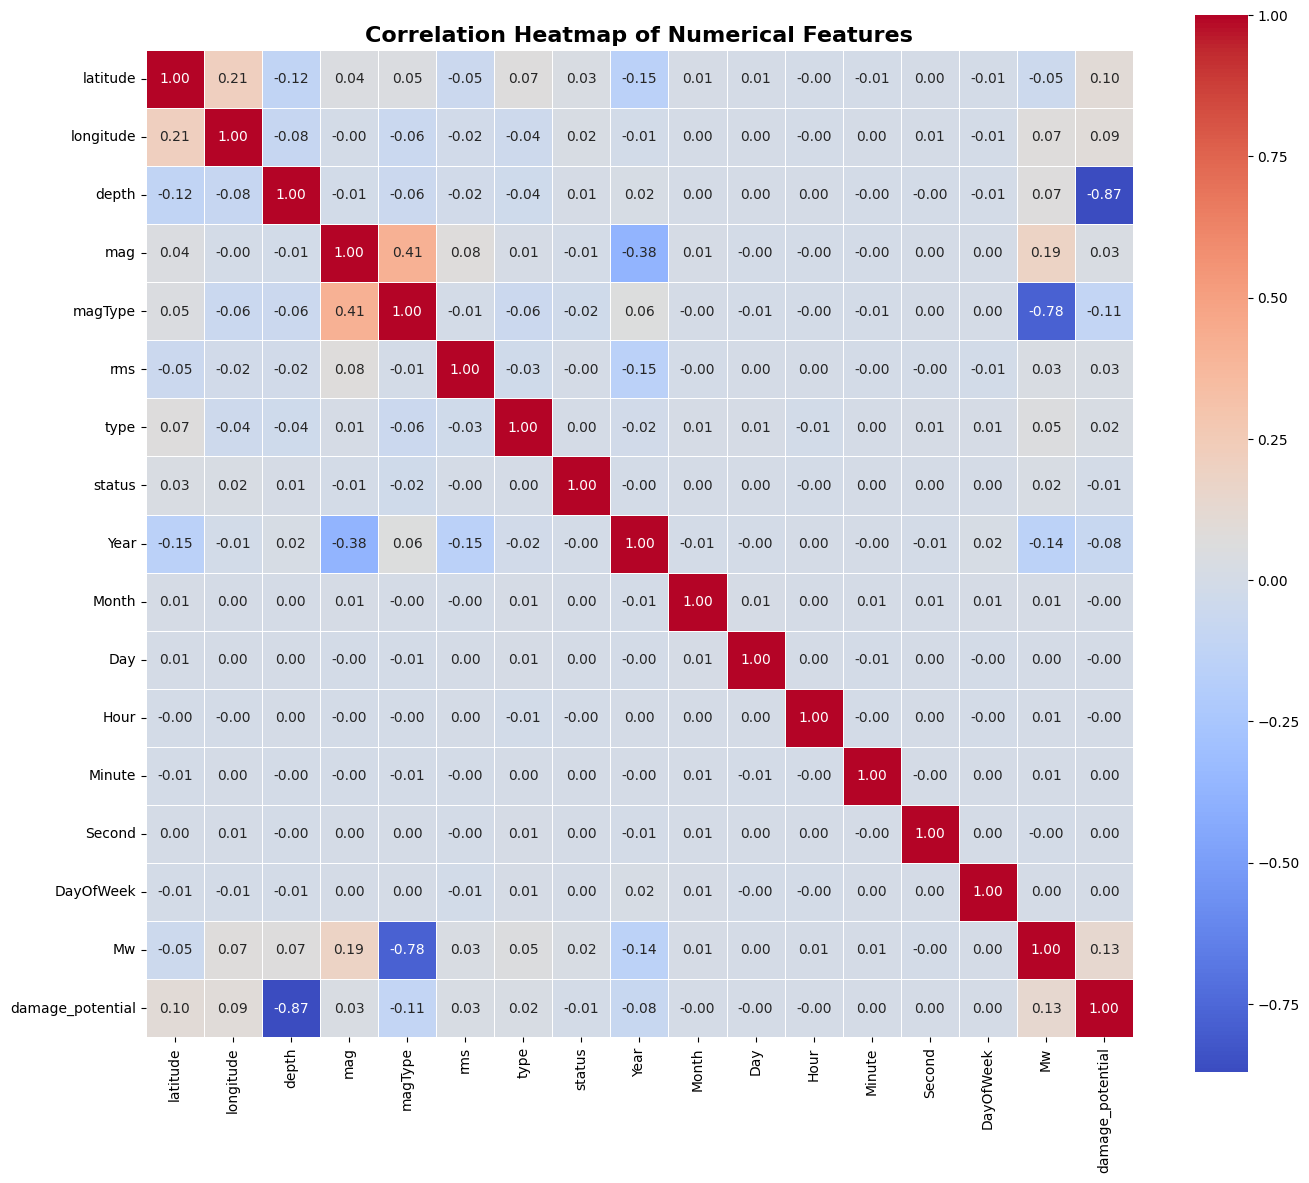

Correlation heatmap saved as 'correlation_heatmap.png'

Calculating Cramér's V for categorical features...


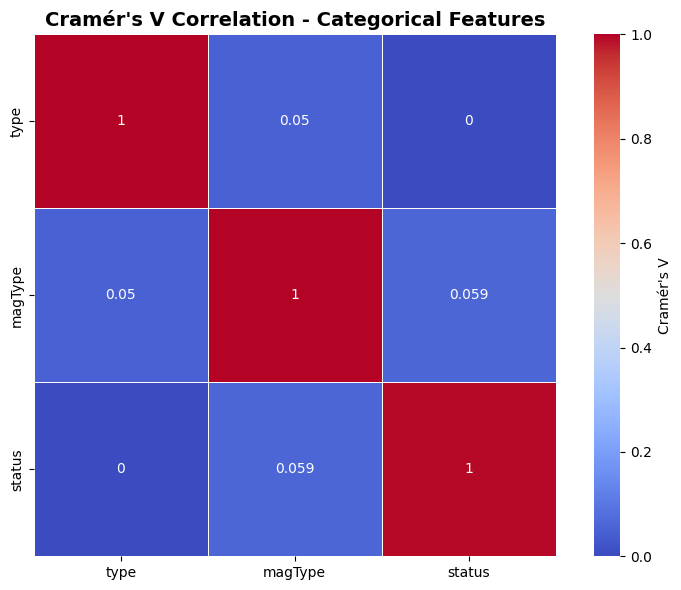

Cramér's V heatmap saved as 'cramers_v_heatmap.png'




In [18]:
print("Correlation Analysis:")
print("-" * 80)

# Step 6.1: Numerical feature correlation
print("Calculating correlation matrix for numerical features...")

# Identify categorical columns
categorical_cols = ['type', 'magType', 'status']
categorical_cols = [col for col in categorical_cols if col in df.columns]

# Create copy for correlation analysis
df_corr = df.copy()

# Encode categorical variables as numeric codes
for col in categorical_cols:
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].astype('category').cat.codes

# Calculate correlation matrix
corr_matrix = df_corr.corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            cbar=True, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved as 'correlation_heatmap.png'\n")


# Step 6.2: Categorical feature correlation (Cramér's V)
if len(categorical_cols) > 1:
    print("Calculating Cramér's V for categorical features...")
    
    def cramers_v(x, y):
        """Calculate Cramér's V statistic for categorical-categorical association"""
        confusion_matrix = pd.crosstab(x, y)
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
        rcorr = r - ((r-1)**2) / (n-1)
        kcorr = k - ((k-1)**2) / (n-1)
        return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1))) if min((kcorr-1), (rcorr-1)) > 0 else 0
    
    # Initialize results DataFrame
    cramers_results = pd.DataFrame(np.zeros((len(categorical_cols), len(categorical_cols))),
                                   index=categorical_cols, columns=categorical_cols)
    
    # Calculate Cramér's V for each pair
    for col1 in categorical_cols:
        for col2 in categorical_cols:
            cramers_results.loc[col1, col2] = cramers_v(df[col1], df[col2])
    
    # Plot heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cramers_results, annot=True, cmap='coolwarm', vmin=0, vmax=1,
                square=True, linewidths=0.5, cbar_kws={'label': "Cramér's V"})
    plt.title("Cramér's V Correlation - Categorical Features", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cramers_v_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Cramér's V heatmap saved as 'cramers_v_heatmap.png'\n")

print("="*80 + "\n")

#### 7. FEATURE SCALING/NORMALIZATION

In [19]:
print("Feature Scaling:")
print("-" * 80)

# Step 7.1: Auto-detect numeric features OR specify manually
# Option A: Auto-detect all numeric columns (recommended for flexibility)
numeric_cols_auto = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude categorical codes if any
for cat_col in categorical_cols:
    if cat_col in numeric_cols_auto:
        numeric_cols_auto.remove(cat_col)

# Option B: Manually specify numeric features to scale (recommended for specific features)
numeric_features = ['depth', 'mag', 'rms']  # Specify critical features to scale
numeric_features = [col for col in numeric_features if col in df.columns]

# Use Option B (manual) if features are specified, otherwise use Option A (auto-detect)
if numeric_features:
    numeric_cols = numeric_features
    print(f"Scaling specified numeric features: {numeric_cols}\n")
else:
    numeric_cols = numeric_cols_auto
    print(f"Scaling auto-detected numeric features: {numeric_cols}\n")

# Step 7.2: Apply Standard Scaling (Z-score normalization)
print("Applying StandardScaler (z-score normalization)...")
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print(f"✓ StandardScaler applied to {len(numeric_cols)} features")
print(f"  Features scaled: {numeric_cols}")

# Step 7.3: Alternative Min-Max Normalization (uncomment to use instead)
# print("Applying MinMaxScaler (0-1 normalization)...")
# normalizer = MinMaxScaler()
# df[numeric_cols] = normalizer.fit_transform(df[numeric_cols])
# print(f"✓ MinMaxScaler applied to {len(numeric_cols)} features")
# print(f"  Features scaled: {numeric_cols}")

print(f"\nScaling Summary:")
print(f"  Total features scaled: {len(numeric_cols)}")
print(f"  Scaling method: StandardScaler (z-score)")
print(f"  Mean of scaled features: {df[numeric_cols].mean().round(4).to_dict()}")
print(f"  Std Dev of scaled features: {df[numeric_cols].std().round(4).to_dict()}")

print("\n" + "="*80 + "\n")


Feature Scaling:
--------------------------------------------------------------------------------
Scaling specified numeric features: ['depth', 'mag', 'rms']

Applying StandardScaler (z-score normalization)...
✓ StandardScaler applied to 3 features
  Features scaled: ['depth', 'mag', 'rms']

Scaling Summary:
  Total features scaled: 3
  Scaling method: StandardScaler (z-score)
  Mean of scaled features: {'depth': -0.0, 'mag': 0.0, 'rms': -0.0}
  Std Dev of scaled features: {'depth': 1.0, 'mag': 1.0, 'rms': 1.0}




#### 8. FINAL DATA SUMMARY

In [20]:
print("Final Preprocessed Data Summary:")
print("-" * 80)

# Display data info
df.info()
print("\n")

# Display sample of preprocessed data
print("Sample Preprocessed Data:")
print(df.head(10))
print("\n")

# Final shape
print(f"Final Dataset Shape: {df.shape}")
print(f"Final Rows: {df.shape[0]}, Final Columns: {df.shape[1]}")
print("\n" + "="*80 + "\n")

Final Preprocessed Data Summary:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 109980 entries, 16 to 110264
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   latitude          109980 non-null  float64
 1   longitude         109980 non-null  float64
 2   depth             109980 non-null  float64
 3   mag               109980 non-null  float64
 4   magType           109980 non-null  object 
 5   rms               109980 non-null  float64
 6   type              109980 non-null  object 
 7   status            109980 non-null  object 
 8   Year              109980 non-null  int32  
 9   Month             109980 non-null  int32  
 10  Day               109980 non-null  int32  
 11  Hour              109980 non-null  int32  
 12  Minute            109980 non-null  int32  
 13  Second            109980 non-null  int32  
 14  DayOfW

#### 9. SAVE PREPROCESSED DATA

In [21]:
print("Saving Preprocessed Data:")
print("-" * 80)

# Save to CSV
output_filename = 'preprocessed_earthquake_data3.csv'
df.to_csv(output_filename, index=False)
print(f"Preprocessed data saved to: {output_filename}")
print(f"File saved with {df.shape[0]} rows and {df.shape[1]} columns")

print("\n" + "="*80)
print("DATA PREPROCESSING PIPELINE COMPLETED SUCCESSFULLY!")
print("="*80)

Saving Preprocessed Data:
--------------------------------------------------------------------------------
Preprocessed data saved to: preprocessed_earthquake_data3.csv
File saved with 109980 rows and 17 columns

DATA PREPROCESSING PIPELINE COMPLETED SUCCESSFULLY!


Observations:

*here we performed complete datapreprocessing.

*we loaded the original dataset and found out missing values and handled them by dropping if more than 30% missing values and dropped unnecessary columns.

*handled missing rms values using linear regression.

*created new feature damage potential using depth and magnitude value(diff magnitude types are scaled into 1 type).

*found correlation of numerical feautures using normal method and for categorical features cramer's rule.

*in feature scaling converting all numeric values into one type using standardscaler where mean=0 and standard deviation=1.

*finally saved the preprocessed data into a csv file.